# Tarea 1

## Statistical Learning

Fancisco Gonzalez

Carnet: 24002914

In [47]:
# Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

## Diccionario de Variables

A continuación se describen las variables utilizadas en el análisis:

Unnamed:0: Índice automático generado al exportar el archivo CSV. No aporta información útil para el análisis.

user_id: Identificador único de cada usuario. Se utiliza para referencia, pero no como predictor.

edad: Edad del usuario expresada en años.

genero: Género del usuario, con valores como "Masculino" o "Femenino".

region: Región geográfica de residencia del usuario, como "Norte", "Centro" o "Sur".

nivel_educacion: Nivel educativo máximo alcanzado por el usuario, con categorías como "Secundaria", "Licenciatura" o "Maestría".

fecha_registro: Fecha en la que el usuario se registró en la plataforma. Potencialmente útil para calcular antigüedad.

plan_suscripcion: Tipo de plan contratado, categorizado en "Básico", "Estándar" o "Premium".

tiempo_uso_promedio_horas: Tiempo promedio de uso semanal de la plataforma por parte del usuario, medido en horas.

frecuencia_acceso_semanal: Número promedio de accesos del usuario a la plataforma en una semana.

satisfaccion_cliente: Nivel de satisfacción percibido del cliente, con categorías como "Alta", "Media" o "Baja".

num_soporte_contactos: Cantidad de veces que el usuario ha contactado al servicio de soporte técnico.

ultima_interaccion: Fecha de la última interacción registrada del usuario en la plataforma.

gasto_total: Gasto total realizado por el usuario en la plataforma, expresado en la moneda local.

dispositivo_principal: Principal dispositivo de acceso utilizado por el usuario, como "Móvil", "Computadora" o "Tablet".

is_churn: Variable objetivo que indica si el usuario abandonó el servicio (1) o permaneció (0).

In [48]:



# Configuramos opciones de visualización para pandas
pd.set_option('display.max_columns', None)

# 1. Cargar el dataset
# ---------------------
# Leemos el archivo CSV llamado 'dataTarea1.csv' y lo almacenamos en un DataFrame
df = pd.read_csv('dataTarea1.csv')

# 2. Exploración Inicial
# -----------------------

# Mostrar las primeras 5 filas del dataset para tener una idea general de los datos
print("Primeras filas del dataset:")
display(df.head())

# Mostrar información general del dataset:
print("\nInformación general del dataset:")
print(df.info())

# Mostrar la cantidad de valores nulos por columna:
print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())




Primeras filas del dataset:


,Unnamed: 0,user_id,edad,genero,region,nivel_educacion,fecha_registro,plan_suscripcion,tiempo_uso_promedio_horas,frecuencia_acceso_semanal,satisfaccion_cliente,num_soporte_contactos,ultima_interaccion,gasto_total,dispositivo_principal,is_churn
0,0,user_1,56,Femenino,Este,Licenciatura,2024-12-09,Basico,0.985993,1,Alta,4,2024-01-19,372.315722,Tablet,0
1,1,user_2,69,Masculino,Norte,Maestría,2024-10-31,Basico,0.046949,6,Muy Baja,3,NaN,12.019278,Movil,0
2,2,user_3,46,Femenino,Norte,Maestría,2023-07-23,Estandar,4.895997,4,Alta,4,2024-05-31,325.161662,Movil,0
3,3,user_4,32,Femenino,Este,Licenciatura,2023-07-15,Basico,13.611662,4,Alta,1,2024-09-16,105.241418,Tablet,0
4,4,user_5,60,Femenino,Sur,Licenciatura,2024-12-28,NaN,2.425298,4,Alta,3,2024-06-12,348.221105,Movil,1



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 1500 non-null   int64  
 1   user_id                    1500 non-null   object 
 2   edad                       1500 non-null   int64  
 3   genero                     1360 non-null   object 
 4   region                     1205 non-null   object 
 5   nivel_educacion            1424 non-null   object 
 6   fecha_registro             1500 non-null   object 
 7   plan_suscripcion           1350 non-null   object 
 8   tiempo_uso_promedio_horas  1500 non-null   float64
 9   frecuencia_acceso_semanal  1500 non-null   int64  
 10  satisfaccion_cliente       1426 non-null   object 
 11  num_soporte_contactos      1500 non-null   int64  
 12  ultima_interaccion         1353 non-null   object 
 13  gasto_total   

In [49]:
#eliminar columnas innecesarias
df.drop(columns=['Unnamed: 0'], inplace=True)
df.drop(columns=['user_id'], inplace=True)

# confivierte fecha_registro  y ultima_interaccion a datetime
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], errors='coerce')
df['ultima_interaccion'] = pd.to_datetime(df['ultima_interaccion'], errors='coerce')


# Mostrar información general del dataset:
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   edad                       1500 non-null   int64         
 1   genero                     1360 non-null   object        
 2   region                     1205 non-null   object        
 3   nivel_educacion            1424 non-null   object        
 4   fecha_registro             1500 non-null   datetime64[ns]
 5   plan_suscripcion           1350 non-null   object        
 6   tiempo_uso_promedio_horas  1500 non-null   float64       
 7   frecuencia_acceso_semanal  1500 non-null   int64         
 8   satisfaccion_cliente       1426 non-null   object        
 9   num_soporte_contactos      1500 non-null   int64         
 10  ultima_interaccion         1353 non-null   datetime64[ns]
 11  gasto_total                1500 non

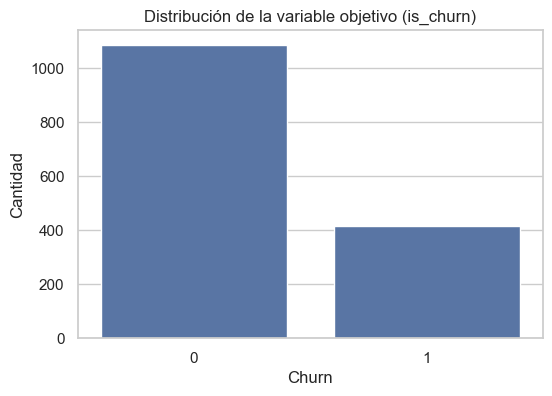

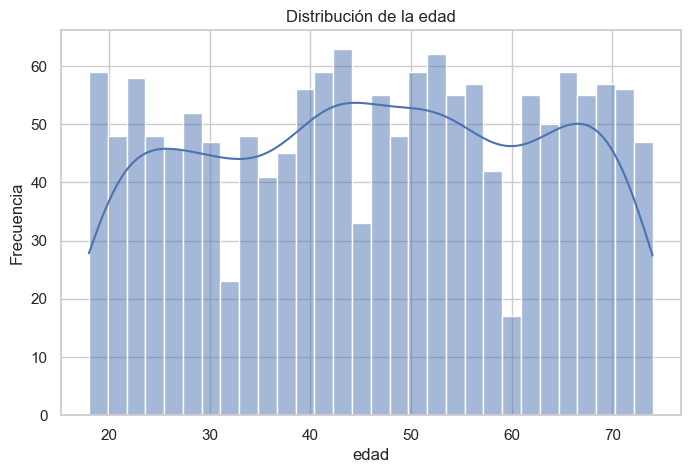

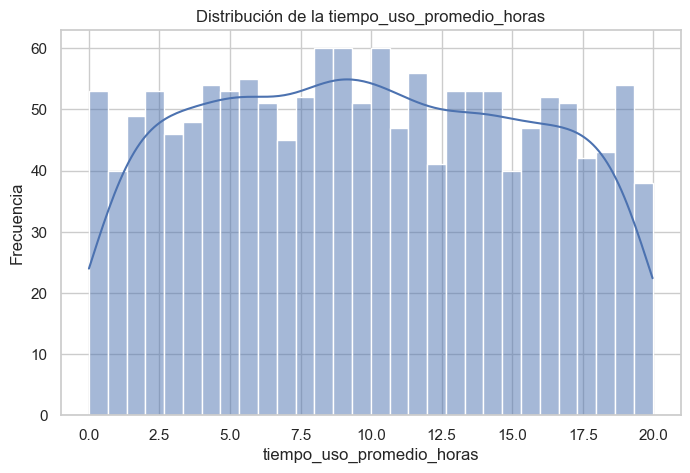

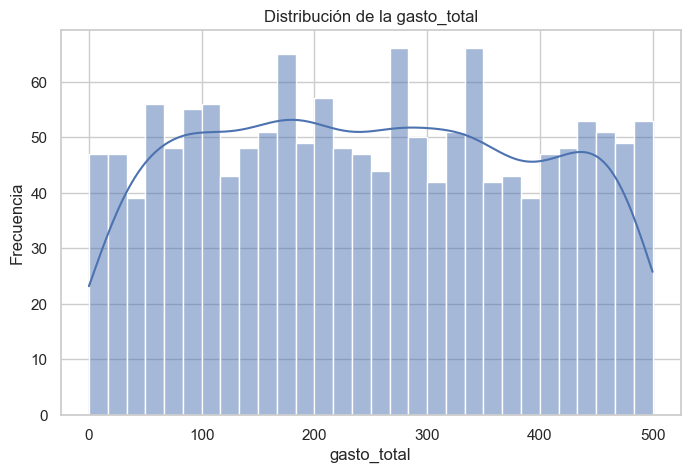

In [50]:
# 3. Visualizaciones Iniciales
# ------------------------------

# Configuramos un estilo general para los gráficos
sns.set(style="whitegrid")

# Visualizar la distribución de la variable objetivo 'is_churn'
plt.figure(figsize=(6,4))
sns.countplot(x='is_churn', data=df)
plt.title('Distribución de la variable objetivo (is_churn)')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.show()

# Visualizar la distribución de una característica numérica (por ejemplo, edad)
# Comprobamos primero si existe una columna de edad
variables_numericas = ['edad', 'tiempo_uso_promedio_horas', 'gasto_total']
for variable in variables_numericas:
    plt.figure(figsize=(8,5))
    sns.histplot(df[variable].dropna(), kde=True, bins=30)
    plt.title(f'Distribución de la {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')
    plt.show()



In [51]:
# 4. Imputación de Datos Faltantes
# ----------------------------------

# Determinamos qué columnas contienen valores faltantes
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("\nColumnas con valores faltantes:")
print(missing_columns)

# Estrategias de imputación
# ----------------------------
# Vamos a utilizar diferentes estrategias dependiendo del tipo de columna:
# - Para columnas numéricas: imputaremos con la media.
# - Para columnas categóricas: imputaremos con la moda (valor más frecuente).

# Recorreremos cada columna con valores faltantes y aplicaremos la estrategia adecuada

for column in missing_columns.index:
    if df[column].dtype in ['float64', 'int64']:
        # Imputación de columnas numéricas con la media
        mean_value = df[column].mean()
        df[column] = df[column].fillna(mean_value)
        print(f"Columna '{column}' imputada con la media: {mean_value:.2f}")
    else:
        # Imputación de columnas categóricas con la moda
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(mode_value)
        print(f"Columna '{column}' imputada con la moda: {mode_value}")


# Verificamos que no haya valores nulos después de la imputación
print("\nCantidad de valores nulos por columna después de la imputación:")
print(df.isnull().sum())



Columnas con valores faltantes:
genero                   140
region                   295
nivel_educacion           76
plan_suscripcion         150
satisfaccion_cliente      74
ultima_interaccion       147
dispositivo_principal     79
dtype: int64
Columna 'genero' imputada con la moda: Femenino
Columna 'region' imputada con la moda: Sur
Columna 'nivel_educacion' imputada con la moda: Licenciatura
Columna 'plan_suscripcion' imputada con la moda: Basico
Columna 'satisfaccion_cliente' imputada con la moda: Media
Columna 'ultima_interaccion' imputada con la moda: 2024-04-21 00:00:00
Columna 'dispositivo_principal' imputada con la moda: Movil

Cantidad de valores nulos por columna después de la imputación:
edad                         0
genero                       0
region                       0
nivel_educacion              0
fecha_registro               0
plan_suscripcion             0
tiempo_uso_promedio_horas    0
frecuencia_acceso_semanal    0
satisfaccion_cliente         0
num_sopor

## Análisis de Codificación de Variables Categóricas

Variables categóricas detectadas:

Son aquellas con tipo object, es decir, texto o categorías no numéricas:

genero

region

nivel_educacion

plan_suscripcion

satisfaccion_cliente

dispositivo_principal

### ¿Qué variables se codificarán? ¿Por qué?

Se codificarán las siguientes variables:

genero

region

nivel_educacion

plan_suscripcion

satisfaccion_cliente

dispositivo_principal

Motivo:

Estas variables representan categorías nominales (no tienen un orden natural entre ellas) y los modelos de Machine Learning requieren entradas numéricas.
Se utilizará One-Hot Encoding porque:

No hay jerarquía entre las categorías.

Evitamos suponer relaciones falsas de orden.

Es seguro para algoritmos basados en distancias o pesos.

### ¿Qué variables no se codificarán? ¿Por qué?

No se codificarán las siguientes variables:

fecha_registro y ultima_interaccion son fechas.



In [52]:
# 5. Codificación  de Variables Categóricas
# -------------------------------------------------

# Primero, definimos las columnas que sí vamos a codificar
columns_to_encode = [
    'genero',
    'region',
    'nivel_educacion',
    'plan_suscripcion',
    'satisfaccion_cliente',
    'dispositivo_principal'
]

# Aplicamos One-Hot Encoding solo sobre esas columnas
# Usamos drop_first=True para evitar multicolinealidad
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

# Mostrar el nuevo shape para comprobar
print(f"Shape original: {df.shape}")
print(f"Shape después de codificar: {df_encoded.shape}")

# Verificar que las columnas categóricas originales ya no están
print("\nColumnas finales después de codificación:")
display(df_encoded.columns.tolist())


Shape original: (1500, 14)
Shape después de codificar: (1500, 23)

Columnas finales después de codificación:


['edad',
 'fecha_registro',
 'tiempo_uso_promedio_horas',
 'frecuencia_acceso_semanal',
 'num_soporte_contactos',
 'ultima_interaccion',
 'gasto_total',
 'is_churn',
 'genero_Masculino',
 'region_Norte',
 'region_Oeste',
 'region_Sur',
 'nivel_educacion_Doctorado',
 'nivel_educacion_Licenciatura',
 'nivel_educacion_Maestría',
 'plan_suscripcion_Estandar',
 'plan_suscripcion_Premium',
 'satisfaccion_cliente_Baja',
 'satisfaccion_cliente_Media',
 'satisfaccion_cliente_Muy Alta',
 'satisfaccion_cliente_Muy Baja',
 'dispositivo_principal_Movil',
 'dispositivo_principal_Tablet']

## Selección de Características

### Características seleccionadas como más importantes:

edad

Relevante porque la edad puede influir en los patrones de uso y cancelación (churn) de un servicio.

plan_suscripcion (codificado)

El tipo de plan contratado tiene un impacto directo en la retención de clientes.

satisfaccion_cliente (codificado)

Es un indicador inmediato del riesgo de churn: clientes insatisfechos tienden a cancelar.

frecuencia_acceso_semanal

Alta o baja frecuencia de uso puede predecir si un usuario se va a ir.

tiempo_uso_promedio_horas

Similar a frecuencia, puede indicar engagement o desinterés.

num_soporte_contactos

Más contactos con soporte pueden indicar problemas y por tanto mayor riesgo de churn.

gasto_total

Usuarios que gastan más o menos pueden tener diferentes tasas de retención.

### Características que NO se seleccionan:

user_id

Es un identificador único, no tiene significado predictivo.

Unnamed: 0

Es un índice generado por error (probablemente al exportar el CSV), no aporta información.

fecha_registro y ultima_interaccion

Son fechas, que requieren ser transformadas (por ejemplo, calcular "antigüedad" o "días desde última actividad") antes de ser útiles. En crudo no se usan.

region, genero, nivel_educacion, dispositivo_principal

Aunque son informativos, no son inicialmente tan fuertes como predictores directos comparados a uso o satisfacción. (Se pueden incluir si el modelo inicial no tiene buen desempeño).


Correlaciones de variables numéricas con 'is_churn':
tiempo_uso_promedio_horas    0.028254
edad                        -0.002868
frecuencia_acceso_semanal   -0.016102
num_soporte_contactos       -0.018252
gasto_total                 -0.021928
Name: is_churn, dtype: float64


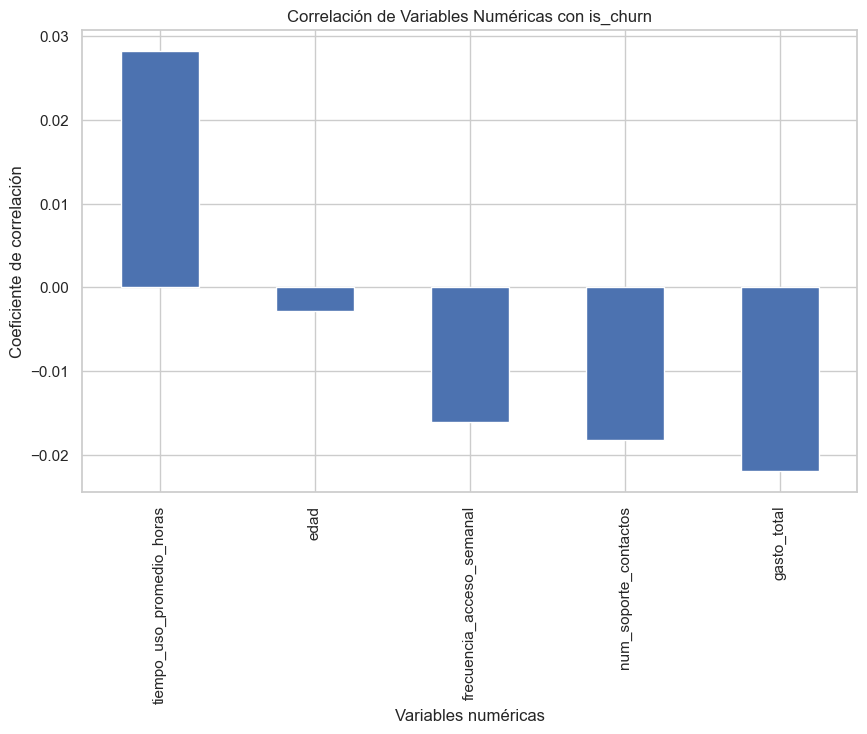


Análisis de variables categóricas con Barplots:


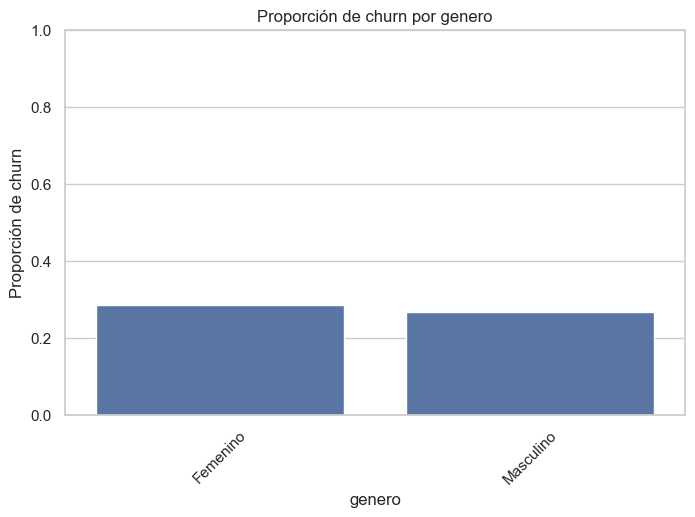

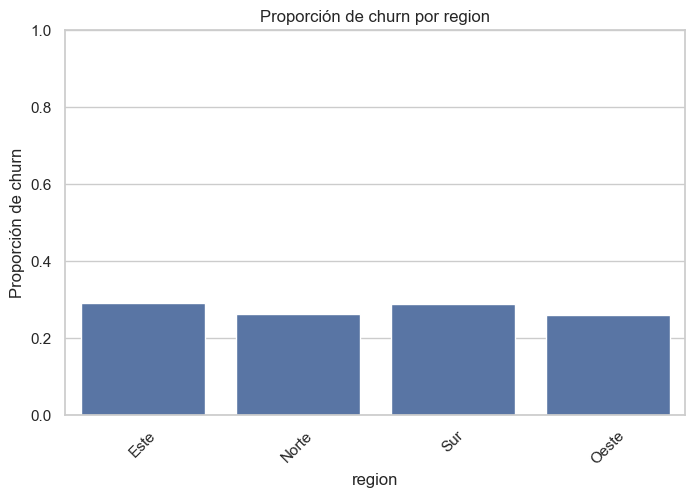

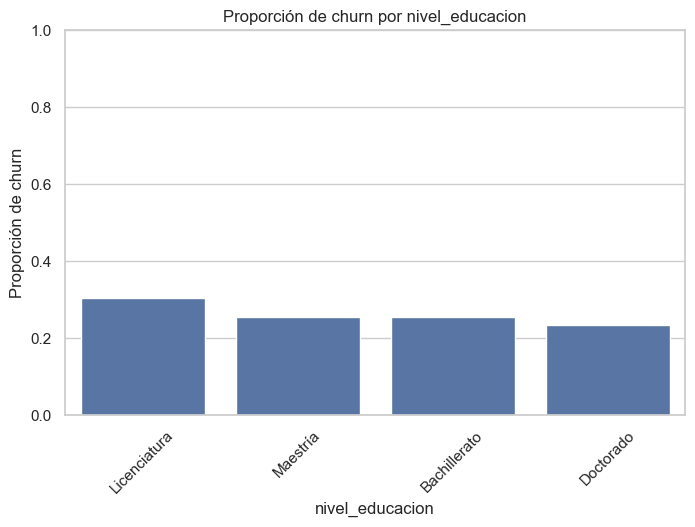

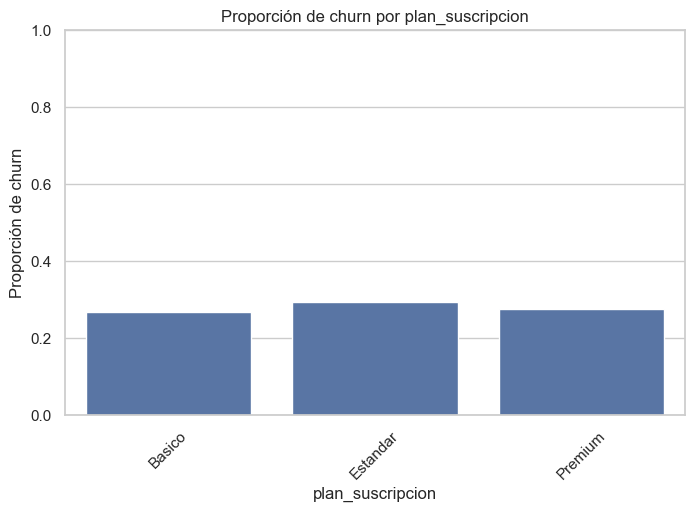

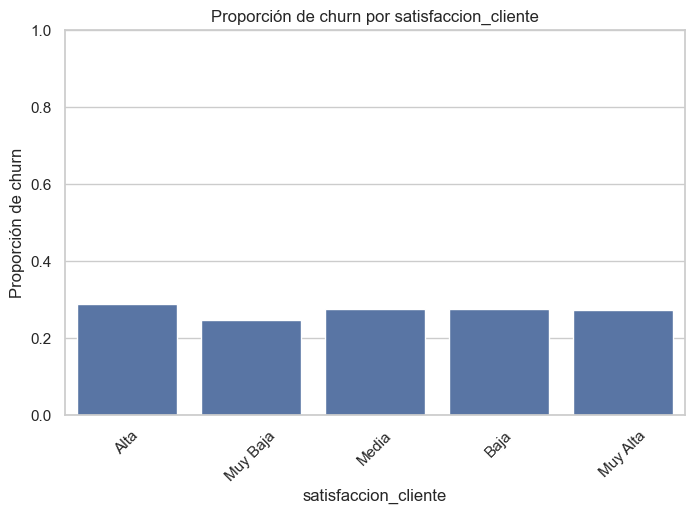

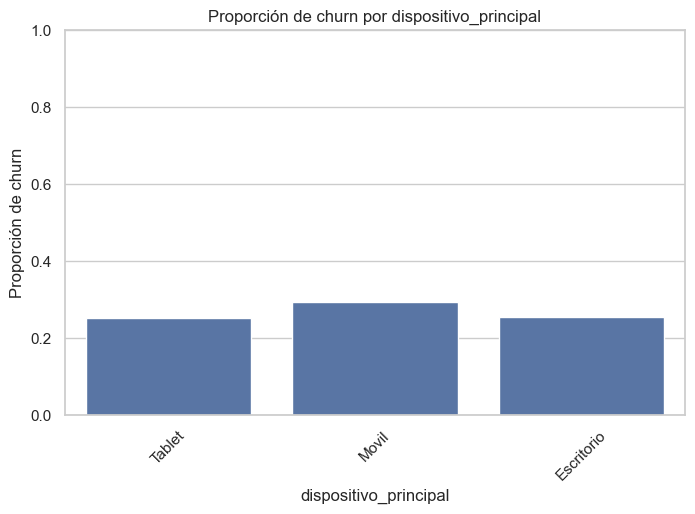


Análisis de variables categóricas codificadas con Barplots:


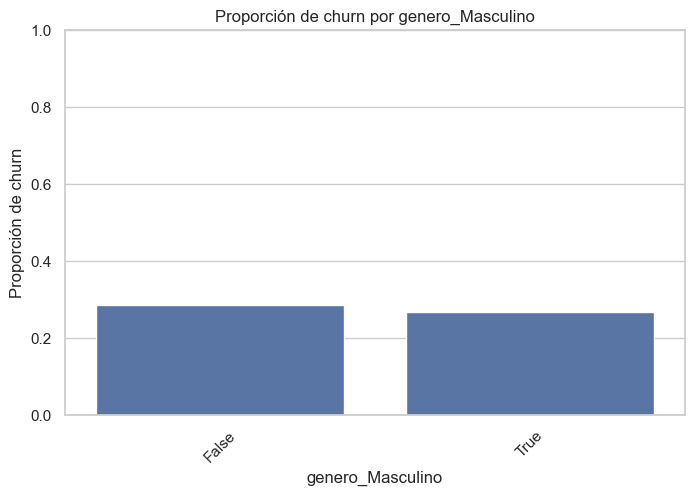

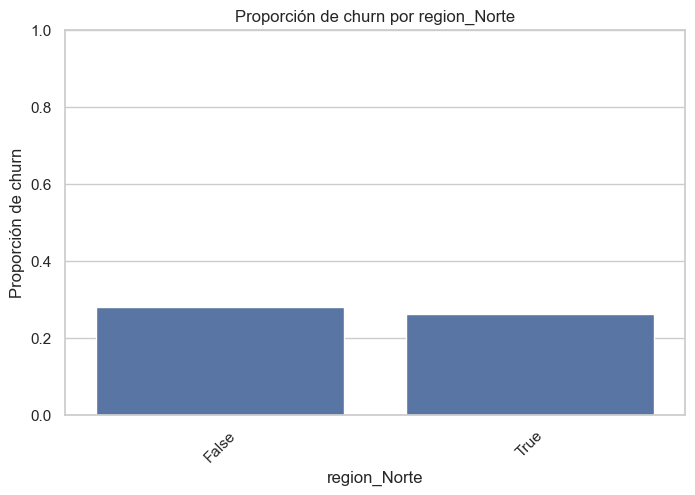

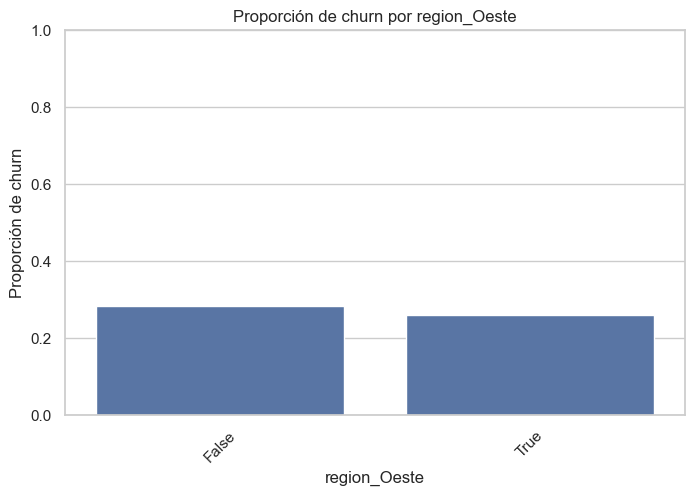

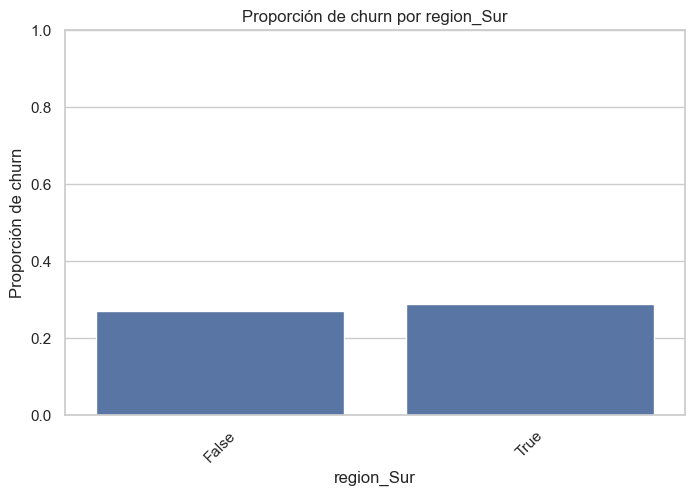

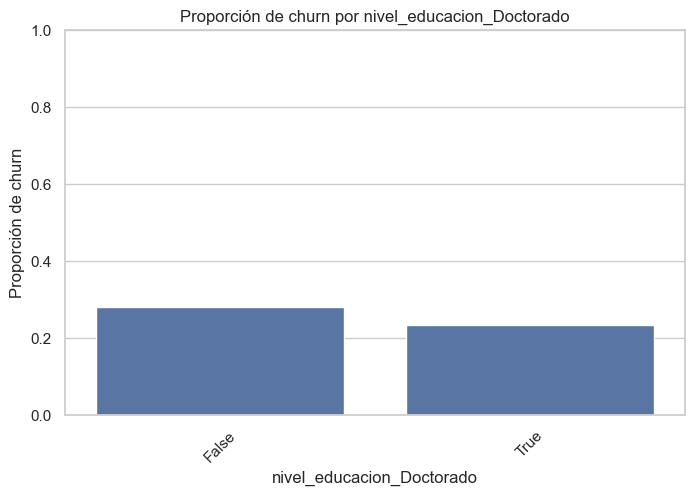

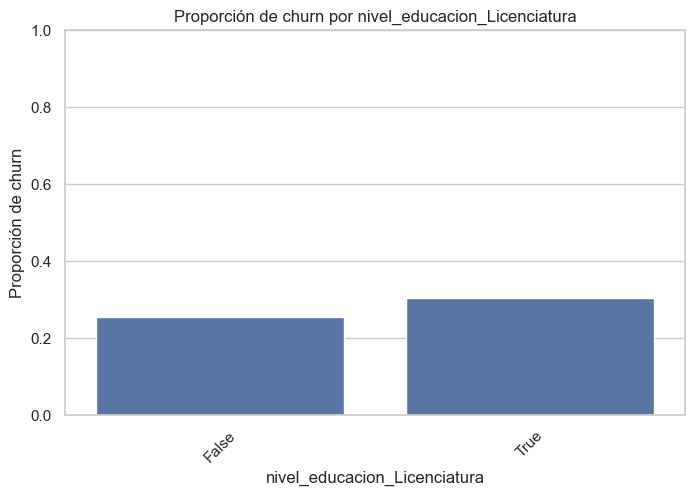

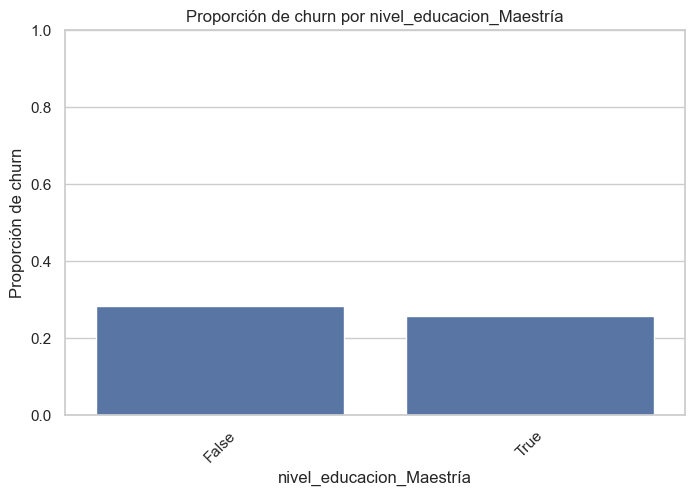

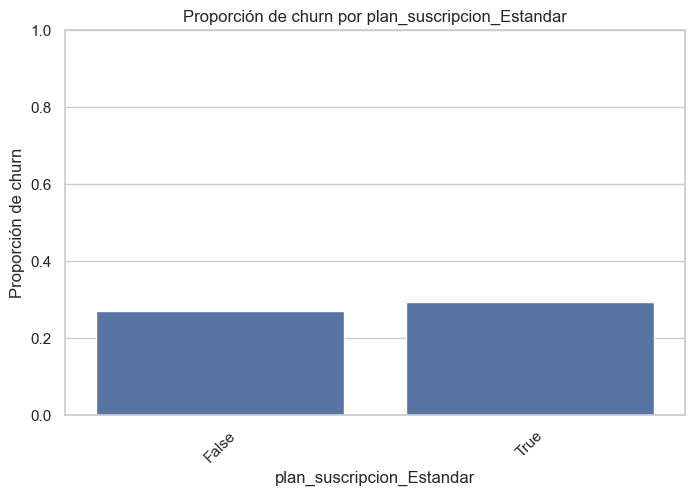

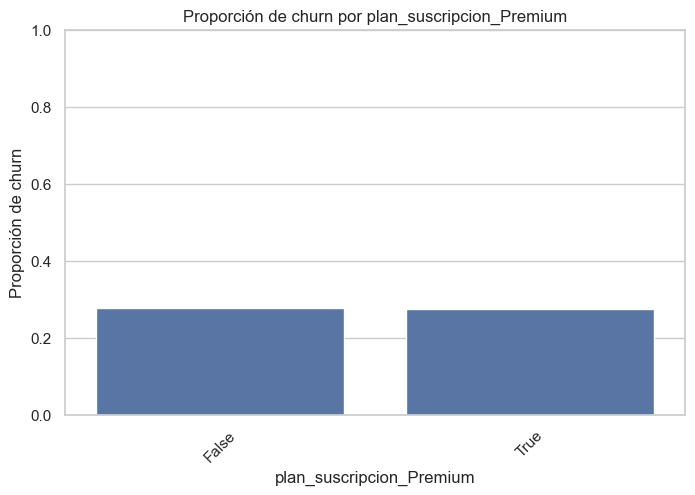

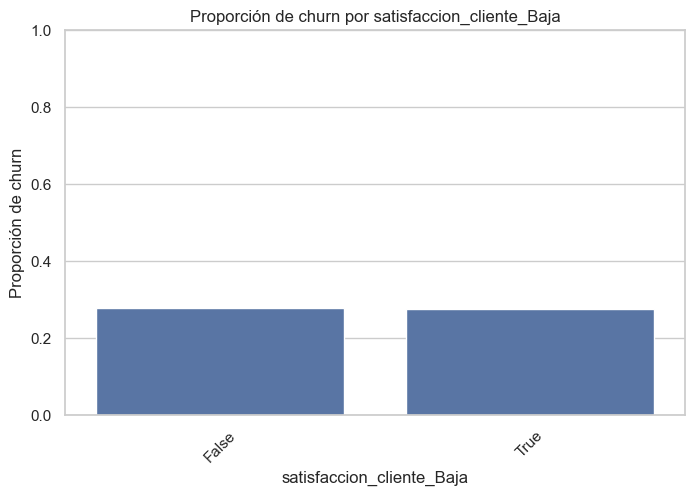

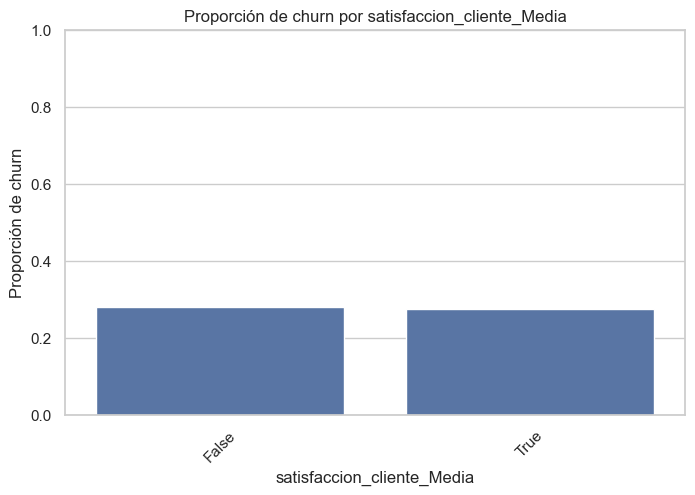

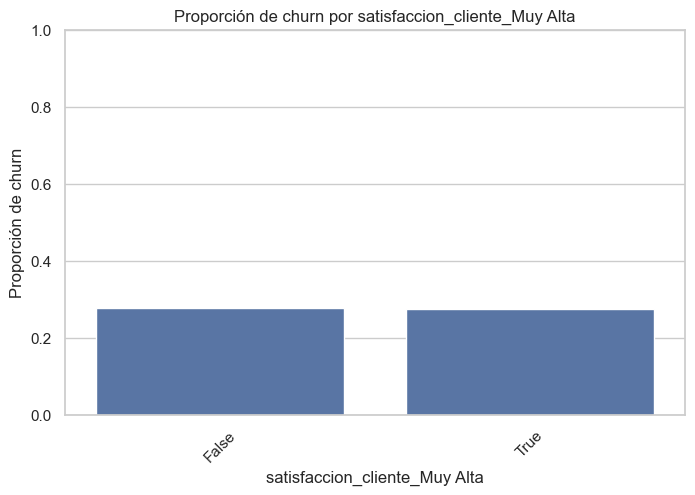

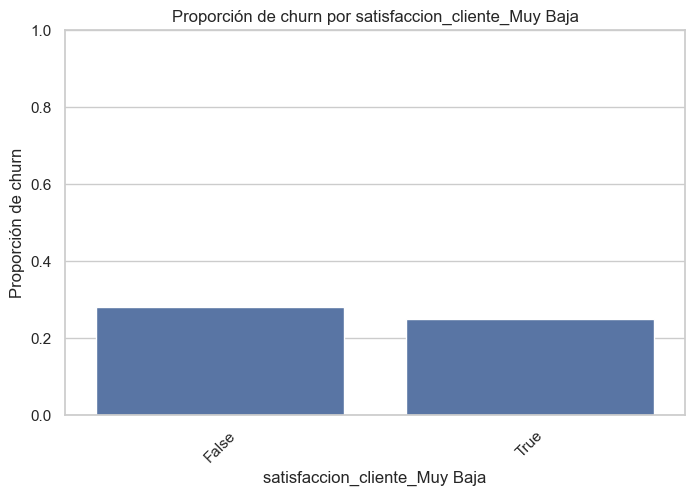

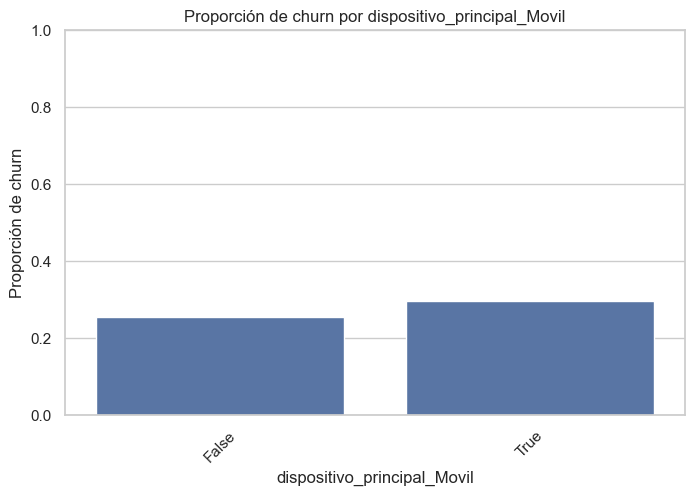

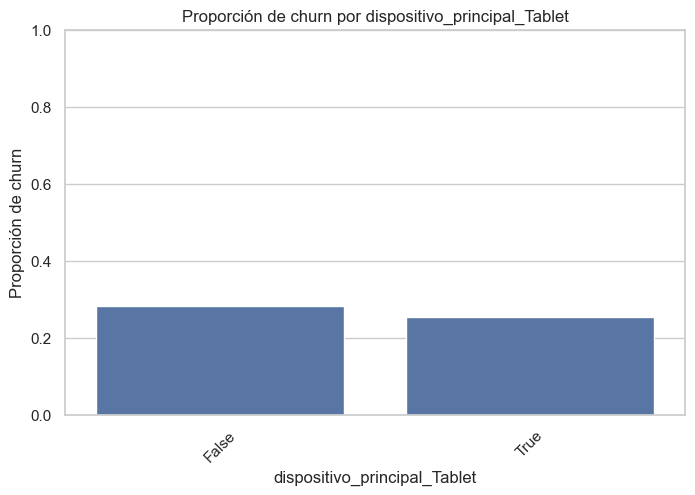

In [53]:
    # 6. Selección de Características
# ----------------------------------


# Primero separamos las variables numéricas
numerical_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Quitamos 'is_churn' porque es la variable objetivo
numerical_features.remove('is_churn')

# 7.1 Análisis de Correlaciones para variables numéricas
# -------------------------------------------------------

# Calculamos la correlación de cada variable numérica con la variable objetivo
correlations = df_encoded[numerical_features + ['is_churn']].corr()['is_churn'].drop('is_churn')

# Mostramos la correlación en orden descendente
print("\nCorrelaciones de variables numéricas con 'is_churn':")
print(correlations.sort_values(ascending=False))

# Podemos visualizar las correlaciones con un gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
correlations.sort_values(ascending=False).plot(kind='bar')
plt.title('Correlación de Variables Numéricas con is_churn')
plt.ylabel('Coeficiente de correlación')
plt.xlabel('Variables numéricas')
plt.show()

# 7.2 Análisis de Variables Categóricas con Barplots
# ----------------------------------------------------
print("\nAnálisis de variables categóricas con Barplots:")
# Recordemos las columnas que codificamos originalmente
categorical_columns = [
    'genero', 'region', 'nivel_educacion',
    'plan_suscripcion', 'satisfaccion_cliente', 'dispositivo_principal'
]
#las columnas categoricas incuyendo las codificadas del df son:
categorical_columns_encoded = [col for col in df_encoded.columns if col.startswith(tuple(categorical_columns))]

# Graficamos el porcentaje promedio de churn para cada categoría
for col in categorical_columns:
    if col in df.columns:
        plt.figure(figsize=(8,5))
        sns.barplot(x=col, y="is_churn", data=df, errorbar=None)
        plt.title(f'Proporción de churn por {col}')
        plt.xlabel(col)
        plt.ylabel('Proporción de churn')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)  # Churn va de 0 a 1
        plt.show()
print("\nAnálisis de variables categóricas codificadas con Barplots:")
# Graficamos el porcentaje promedio de churn para cada categoría
for col in categorical_columns_encoded:
    if col in df_encoded.columns:
        plt.figure(figsize=(8,5))
        sns.barplot(x=col, y="is_churn", data=df_encoded, errorbar=None)
        plt.title(f'Proporción de churn por {col}')
        plt.xlabel(col)
        plt.ylabel('Proporción de churn')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)  # Porque churn va de 0 a 1
        plt.show()


## Variables Numéricas (por correlación con is_churn)

Basado en el gráfico de correlaciones:

tiempo_uso_promedio_horas
→ Tiene una correlación positiva interesante con is_churn.

edad
→ Aunque su correlación es baja, la edad puede influir en la probabilidad de cancelar.

frecuencia_acceso_semanal, num_soporte_contactos, gasto_total
→ Tienen correlaciones negativas bajas, pero siguen siendo relevantes para analizar comportamiento.


## Variables Categóricas (por barplots)

Basado en los barplots, observamos diferencias entre categorías en varias variables:

genero

region

nivel_educacion

plan_suscripcion

satisfaccion_cliente

dispositivo_principal

Estas variables muestran diferencias ligeramente visibles en las distribuciones (no extremas), así que se mantienen para modelar porque pueden aportar valor predictivo.

Tipo | Variables Seleccionadas

Numéricas | tiempo_uso_promedio_horas, edad, frecuencia_acceso_semanal, num_soporte_contactos, gasto_total

Categóricas | genero, region, nivel_educacion, plan_suscripcion, satisfaccion_cliente, dispositivo_principal

In [54]:
# 7. Mostrar el Dataset Preparado usando display()
# ---------------------------------------------------


# Definimos las columnas finales seleccionadas
final_features = [
    'tiempo_uso_promedio_horas',
    'edad',
    'frecuencia_acceso_semanal',
    'num_soporte_contactos',
    'gasto_total',
    # Variables categóricas codificadas:
]

# Buscamos las columnas categóricas codificadas
categorical_encoded_columns = [col for col in df_encoded.columns if
                                col.startswith('genero_') or
                                col.startswith('region_') or
                                col.startswith('nivel_educacion_') or
                                col.startswith('plan_suscripcion_') or
                                col.startswith('satisfaccion_cliente_') or
                                col.startswith('dispositivo_principal_')]

# Juntamos todas las columnas
final_features += categorical_encoded_columns

# No olvidamos la variable objetivo
final_features.append('is_churn')

# Creamos el dataframe final
df_final = df_encoded[final_features]

# Mostramos el dataframe final de forma limpia
print("\nDataset preparado (muestra de 25):")
display(df_final.sample(25))



Dataset preparado (muestra de 25):


,tiempo_uso_promedio_horas,edad,frecuencia_acceso_semanal,num_soporte_contactos,gasto_total,genero_Masculino,region_Norte,region_Oeste,region_Sur,nivel_educacion_Doctorado,nivel_educacion_Licenciatura,nivel_educacion_Maestría,plan_suscripcion_Estandar,plan_suscripcion_Premium,satisfaccion_cliente_Baja,satisfaccion_cliente_Media,satisfaccion_cliente_Muy Alta,satisfaccion_cliente_Muy Baja,dispositivo_principal_Movil,dispositivo_principal_Tablet,is_churn
144,4.689680,57,2,3,303.662296,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,1
516,2.606479,33,5,4,136.910310,True,False,True,False,False,True,False,True,False,False,True,False,False,True,False,0
662,1.397238,52,0,3,296.350319,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,0
372,16.945935,24,4,4,213.993086,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,0
371,11.755908,25,4,2,21.468077,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,0
68,4.220134,31,4,1,276.591746,True,True,False,False,False,True,False,True,False,False,False,False,False,True,False,1
1127,2.905720,51,3,3,15.902766,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0
1266,0.115413,52,5,4,392.494654,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,0
540,8.830946,71,2,1,17.869276,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
799,13.282515,61,6,3,54.012660,True,True,False,False,False,True,False,False,False,False,False,False,False,True,False,0
